In [1]:
!pip show torch

Name: torch
Version: 2.7.1+cu118
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: C:\Users\gol_m\anaconda3\envs\eie_iag\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: torchaudio, torchvision


Requerimiento: En mi pc tengo una GTX 1050, por tanto, tuve que instalar esta versión de torch:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
```

In [1]:
USE_BASE_MODEL = False
USE_REASONING_MODEL = True
USE_INSTRUCT_MODEL = False

In [2]:
import torch
import torch.nn as nn

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], dtype=cfg["dtype"], bias=False)

    def forward(self, x):
        x_fc1 = self.fc1(x)
        x_fc2 = self.fc2(x)
        x = nn.functional.silu(x_fc1) * x_fc2
        return self.fc3(x)
    
class RMSNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-6, bias=False, qwen3_compatible=True):
        super().__init__()
        self.eps = eps
        self.qwen3_compatible = qwen3_compatible
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim)) if bias else None

    def forward(self, x):
        input_dtype = x.dtype

        if self.qwen3_compatible:
            x = x.to(torch.float32)

        variance = x.pow(2).mean(dim=-1, keepdim=True)
        norm_x = x * torch.rsqrt(variance + self.eps)
        norm_x = norm_x * self.scale

        if self.shift is not None:
            norm_x = norm_x + self.shift

        return norm_x.to(input_dtype)
    
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096, dtype=torch.float32):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))

    # Generate position indices
    positions = torch.arange(context_length, dtype=dtype)

    # Compute the angles
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin


def apply_rope(x, cos, sin):
    # x: (batch_size, num_heads, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Split x into first half and second half
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2 :]  # Second half

    # Adjust sin and cos shapes
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    # It's ok to use lower-precision after applying cos and sin rotation
    return x_rotated.to(dtype=x.dtype)

class GroupedQueryAttention(nn.Module):
    def __init__(
        self, d_in, num_heads, num_kv_groups, head_dim=None, qk_norm=False, dtype=None
    ):
        super().__init__()
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

        self.num_heads = num_heads
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups

        if head_dim is None:
            assert d_in % num_heads == 0, "`d_in` must be divisible by `num_heads` if `head_dim` is not set"
            head_dim = d_in // num_heads

        self.head_dim = head_dim
        self.d_out = num_heads * head_dim

        self.W_query = nn.Linear(d_in, self.d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)

        self.out_proj = nn.Linear(self.d_out, d_in, bias=False, dtype=dtype)

        if qk_norm:
            self.q_norm = RMSNorm(head_dim, eps=1e-6)
            self.k_norm = RMSNorm(head_dim, eps=1e-6)
        else:
            self.q_norm = self.k_norm = None

        # AGREGAR ESTA LÍNEA:
        self.attn_weights = None  # ← NUEVA LÍNEA

    def forward(self, x, mask, cos, sin):
        b, num_tokens, _ = x.shape

        # Apply projections
        queries = self.W_query(x)  # (b, num_tokens, num_heads * head_dim)
        keys = self.W_key(x)       # (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)   # (b, num_tokens, num_kv_groups * head_dim)

        # Reshape
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)

        # Optional normalization
        if self.q_norm:
            queries = self.q_norm(queries)
        if self.k_norm:
            keys = self.k_norm(keys)

        # Apply RoPE
        queries = apply_rope(queries, cos, sin)
        keys = apply_rope(keys, cos, sin)

        # Expand K and V to match number of heads
        keys = keys.repeat_interleave(self.group_size, dim=1)
        values = values.repeat_interleave(self.group_size, dim=1)

        # Attention
        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)
        attn_weights = torch.softmax(attn_scores / self.head_dim**0.5, dim=-1)

        # AGREGAR ESTAS 2 LÍNEAS después del softmax:
        self.attn_weights = attn_weights.detach()  # ← NUEVA LÍNEA

        context = (attn_weights @ values).transpose(1, 2).reshape(b, num_tokens, self.d_out)
        return self.out_proj(context)
    
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            head_dim=cfg["head_dim"],
            num_kv_groups=cfg["n_kv_groups"],
            qk_norm=cfg["qk_norm"],
            dtype=cfg["dtype"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.norm2 = RMSNorm(cfg["emb_dim"], eps=1e-6)

    def forward(self, x, mask, cos, sin):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x, mask, cos, sin)  # Shape [batch_size, num_tokens, emb_size]
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = x + shortcut  # Add the original input back

        return x
    
class Qwen3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Main model parameters
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])

        self.trf_blocks = nn.ModuleList(  # ModuleList since Sequential can only accept one input, and we need `x, mask, cos, sin`
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = RMSNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

        # Reusuable utilities
        if cfg["head_dim"] is None:
            head_dim = cfg["emb_dim"] // cfg["n_heads"]
        else:
            head_dim = cfg["head_dim"]
        cos, sin = compute_rope_params(
            head_dim=head_dim,
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"]
        )
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        self.cfg = cfg


    def forward(self, in_idx):
        # Forward pass
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds

        num_tokens = x.shape[1]
        mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)

        for block in self.trf_blocks:
            x = block(x, mask, self.cos, self.sin)
        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg["dtype"]))
        return logits

In [3]:
CHOOSE_MODEL = "0.6B"

if CHOOSE_MODEL == "0.6B":
    QWEN3_CONFIG = {
        "vocab_size": 151_936,           # Vocabulary size
        "context_length": 40_960,        # Context length that was used to train the model
        "emb_dim": 1024,                 # Embedding dimension
        "n_heads": 16,                   # Number of attention heads
        "n_layers": 28,                  # Number of layers
        "hidden_dim": 3072,              # Size of the intermediate dimension in FeedForward
        "head_dim": 128,                 # Size of the heads in GQA
        "qk_norm": True,                 # Whether to normalize queries and keys in GQA
        "n_kv_groups": 8,                # Key-Value groups for grouped-query attention
        "rope_base": 1_000_000.0,        # The base in RoPE's "theta"
        "dtype": torch.bfloat16,         # Lower-precision dtype to reduce memory usage
    }

elif CHOOSE_MODEL == "1.7B":
    QWEN3_CONFIG = {
        "vocab_size": 151_936,
        "context_length": 40_960,
        "emb_dim": 2048,                 # 2x larger than above
        "n_heads": 16,
        "n_layers": 28,
        "hidden_dim": 6144,              # 2x larger than above
        "head_dim": 128,
        "qk_norm": True,
        "n_kv_groups": 8,
        "rope_base": 1_000_000.0,
        "dtype": torch.bfloat16,
    }

elif CHOOSE_MODEL == "4B":
    QWEN3_CONFIG = {
        "vocab_size": 151_936,
        "context_length": 40_960,
        "emb_dim": 2560,                 # 25% larger than above
        "n_heads": 32,                   # 2x larger than above
        "n_layers": 36,                  # 29% larger than above
        "hidden_dim": 9728,              # ~3x larger than above
        "head_dim": 128,
        "qk_norm": True,
        "n_kv_groups": 8,
        "rope_base": 1_000_000.0,
        "dtype": torch.bfloat16,
    }

elif CHOOSE_MODEL == "8B":
    QWEN3_CONFIG = {
        "vocab_size": 151_936,
        "context_length": 40_960,
        "emb_dim": 4096,                 # 60% larger than above
        "n_heads": 32,
        "n_layers": 36,                  # 26% larger than above
        "hidden_dim": 12288,
        "head_dim": 128,
        "qk_norm": True,
        "n_kv_groups": 8,
        "rope_base": 1_000_000.0,
        "dtype": torch.bfloat16,
    }

elif CHOOSE_MODEL == "14B":
    QWEN3_CONFIG = {
        "vocab_size": 151_936,
        "context_length": 40_960,
        "emb_dim": 5120,                 # 25% larger than above
        "n_heads": 40,                   # 25% larger than above
        "n_layers": 40,                  # 11% larger than above
        "hidden_dim": 17408,             # 42% larger than above
        "head_dim": 128,
        "qk_norm": True,
        "n_kv_groups": 8,
        "rope_base": 1_000_000.0,
        "dtype": torch.bfloat16,
    }

elif CHOOSE_MODEL == "32B":
    QWEN3_CONFIG = {
        "vocab_size": 151_936,
        "context_length": 40_960,
        "emb_dim": 5120,
        "n_heads": 64,                   # 60% larger than above
        "n_layers": 64,                  # 60% larger than above
        "hidden_dim": 25600,             # 47% larger than above
        "head_dim": 128,
        "qk_norm": True,
        "n_kv_groups": 8,
        "rope_base": 1_000_000.0,
        "dtype": torch.bfloat16,
    }

else:
    raise ValueError(f"{CHOOSE_MODEL} is not supported.")

35s tarda en cargar el modelo de 0.6B

In [4]:
torch.manual_seed(123)

model = Qwen3Model(QWEN3_CONFIG)

In [5]:
# model

Realizamos un pequeño fordward pass para verificar.

Importante: La matriz que retorna el LLM será de tamaño 151936, que equivale al tamaño del vocab size.

In [ ]:
input_tensor = torch.tensor([1, 2, 3]).unsqueeze(0)
response_llm = model(input_tensor)

# Mostrar què responde el LLMs
# response_llm.shape

torch.Size([1, 3, 151936])

In [5]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Número total de parametros: {total_params:,}")

# Account for weight tying
# total_params_normalized = total_params - model.tok_emb.weight.numel()
# print(f"\nTotal number of unique parameters: {total_params_normalized:,}")

Número total de parametros: 751,632,384


In [ ]:
751,632,384

In [6]:
def model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024**3)

    return total_memory_gb

print(f"float32 (PyTorch default): {model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

float32 (PyTorch default): 5.64 GB
bfloat16: 2.82 GB


In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)

Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

## **Cargar pesos pre-entrenados**

In [8]:
def load_weights_into_qwen(model, param_config, params):
    def assign(left, right, tensor_name="unknown"):
        if left.shape != right.shape:
            raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

        with torch.no_grad():
            if isinstance(right, torch.Tensor):
                left.copy_(right)
            else:
                left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

        return left

    model.tok_emb.weight = assign(model.tok_emb.weight, params["model.embed_tokens.weight"], "model.embed_tokens.weight")

    for l in range(param_config["n_layers"]):
        block = model.trf_blocks[l]
        att = block.att

        # Q, K, V projections
        att.W_query.weight = assign(
            att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        att.W_key.weight = assign(
            att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        att.W_value.weight = assign(
            att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )

        # Output projection
        att.out_proj.weight = assign(
            att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )

        # QK norms
        if hasattr(att, "q_norm") and att.q_norm is not None:
            att.q_norm.scale = assign(
                att.q_norm.scale,
                params[f"model.layers.{l}.self_attn.q_norm.weight"],
                f"model.layers.{l}.self_attn.q_norm.weight"
            )
        if hasattr(att, "k_norm") and att.k_norm is not None:
            att.k_norm.scale = assign(
                att.k_norm.scale,
                params[f"model.layers.{l}.self_attn.k_norm.weight"],
                f"model.layers.{l}.self_attn.k_norm.weight"
            )

        # Attention layernorm
        block.norm1.scale = assign(
            block.norm1.scale,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Feedforward weights
        block.ff.fc1.weight = assign(
            block.ff.fc1.weight,
            params[f"model.layers.{l}.mlp.gate_proj.weight"],
            f"model.layers.{l}.mlp.gate_proj.weight"
        )
        block.ff.fc2.weight = assign(
            block.ff.fc2.weight,
            params[f"model.layers.{l}.mlp.up_proj.weight"],
            f"model.layers.{l}.mlp.up_proj.weight"
        )
        block.ff.fc3.weight = assign(
            block.ff.fc3.weight,
            params[f"model.layers.{l}.mlp.down_proj.weight"],
            f"model.layers.{l}.mlp.down_proj.weight"
        )
        block.norm2.scale = assign(
            block.norm2.scale,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Final normalization and output head
    model.final_norm.scale = assign(model.final_norm.scale, params["model.norm.weight"], "model.norm.weight")

    if "lm_head.weight" in params:
        model.out_head.weight = assign(model.out_head.weight, params["lm_head.weight"], "lm_head.weight")
    else:
        model.out_head.weight = model.tok_emb.weight
        print("Model uses weight tying.")

In [9]:
import json
import os
from pathlib import Path
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download, snapshot_download


if USE_REASONING_MODEL or USE_INSTRUCT_MODEL:
    repo_id = f"Qwen/Qwen3-{CHOOSE_MODEL}"
else:
    repo_id = f"Qwen/Qwen3-{CHOOSE_MODEL}-Base"

local_dir = Path(repo_id).parts[-1]

if CHOOSE_MODEL == "0.6B":
    weights_file = hf_hub_download(
        repo_id=repo_id,
        filename="model.safetensors",
        local_dir=local_dir,
    )
    weights_dict = load_file(weights_file)
else:
    repo_dir = snapshot_download(repo_id=repo_id, local_dir=local_dir)
    index_path = os.path.join(repo_dir, "model.safetensors.index.json")
    with open(index_path, "r") as f:
        index = json.load(f)

    weights_dict = {}
    for filename in set(index["weight_map"].values()):
        shard_path = os.path.join(repo_dir, filename)
        shard = load_file(shard_path)
        weights_dict.update(shard)

load_weights_into_qwen(model, QWEN3_CONFIG, weights_dict)
model.to(device)
del weights_dict

c:\Users\gol_m\anaconda3\envs\programacion_2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [10]:
import re
from tokenizers import Tokenizer

class Qwen3Tokenizer:
    _SPECIALS = [
        "<|endoftext|>",
        "<|im_start|>", "<|im_end|>",
        "<|object_ref_start|>", "<|object_ref_end|>",
        "<|box_start|>", "<|box_end|>",
        "<|quad_start|>", "<|quad_end|>",
        "<|vision_start|>", "<|vision_end|>",
        "<|vision_pad|>", "<|image_pad|>", "<|video_pad|>",
        "<think>", "</think>"
    ]
    _SPLIT_RE = re.compile(r"(<\|[^>]+?\|>|<think>|</think>)")

    def __init__(self, tokenizer_file_path="tokenizer.json", repo_id=None,
                 apply_chat_template=True, add_generation_prompt=False, add_thinking=False):

        self.apply_chat_template = apply_chat_template
        self.add_generation_prompt = add_generation_prompt
        self.add_thinking = add_thinking

        tok_file = Path(tokenizer_file_path)
        self._tok = Tokenizer.from_file(str(tok_file))
        self._special_to_id = {}
        for t in self._SPECIALS:
            tid = self._tok.token_to_id(t)
            if tid is not None:
                self._special_to_id[t] = tid

        self.pad_token_id = self._special_to_id["<|endoftext|>"]
        self.eos_token_id = self.pad_token_id

        if repo_id and "Base" not in repo_id:
            eos_token = "<|im_end|>"
        else:
            eos_token = "<|endoftext|>"
        if eos_token in self._special_to_id:
            self.eos_token_id = self._special_to_id[eos_token]

    def encode(self, text, chat_wrapped=None):
        if chat_wrapped is None:
            chat_wrapped = self.apply_chat_template

        stripped = text.strip()
        if stripped in self._special_to_id and "\n" not in stripped:
            return [self._special_to_id[stripped]]

        if chat_wrapped:
            text = self._wrap_chat(text)

        ids = []
        for part in filter(None, self._SPLIT_RE.split(text)):
            if part in self._special_to_id:
                ids.append(self._special_to_id[part])
            else:
                ids.extend(self._tok.encode(part).ids)
        return ids

    def decode(self, ids):
        return self._tok.decode(ids, skip_special_tokens=False)

    def _wrap_chat(self, user_msg):
        s = f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        if self.add_generation_prompt:
            s += "<|im_start|>assistant"
            if self.add_thinking:
                s += "\n"
            else:
                s += "\n<think>\n\n</think>\n\n"
        return s

In [11]:
if USE_REASONING_MODEL:
    tokenizer_file_path = f"Qwen3-{CHOOSE_MODEL}/tokenizer.json"
else:
    tokenizer_file_path = f"Qwen3-{CHOOSE_MODEL}-Base/tokenizer.json"

hf_hub_download(
    repo_id=repo_id,
    filename="tokenizer.json",
    local_dir=local_dir,
)

if USE_REASONING_MODEL or USE_INSTRUCT_MODEL:
    tokenizer = Qwen3Tokenizer(
        tokenizer_file_path=tokenizer_file_path,
        repo_id=repo_id,
        apply_chat_template=True,
        add_generation_prompt=True,
        add_thinking=USE_REASONING_MODEL
    )

else:
    tokenizer = Qwen3Tokenizer(
        tokenizer_file_path=tokenizer_file_path,
        repo_id=repo_id,
        apply_chat_template=False,
        add_generation_prompt=False,
        add_thinking=False
    )

## **Generar una respuesta**

In [12]:
def generate_text_basic_stream(model, token_ids, max_new_tokens, eos_token_id=None):

    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(token_ids)[:, -1]
            next_token = torch.argmax(out, dim=-1, keepdim=True)

            if (eos_token_id is not None
                   and torch.all(next_token == eos_token_id)):
               print("Predijo el token de termino de secuencia")
               break

            yield next_token

            token_ids = torch.cat([token_ids, next_token], dim=1)

In [13]:
prompt = "Holas me llamo Gabriel Olmos Leiva!"

input_token_ids = tokenizer.encode(prompt)

input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)

for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=500,
    eos_token_id=tokenizer.eos_token_id
):
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True
    )

<think>
Okay, the user is Gabriel Olmos Leiva, and I need to respond to him. Let me start by acknowledging his name. I should make sure to greet him properly. Maybe say "Hola Gabriel!" and then ask how he's doing. Keep the tone friendly and open. Let me check if there's any specific information I should include, but since he just said his name, a simple greeting should suffice. Avoid any unnecessary details. Alright, that should cover it.
</think>

Hola Gabriel! ¡Qué bien te ha ido! ¿Cómo estás? Si tienes alguna pregunta o necesitas ayuda, ¡avísame! ���Predijo el token de termino de secuencia


In [14]:
prompt = "en realidad estás pensando?"

input_token_ids = tokenizer.encode(prompt)

input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)

for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=500,
    eos_token_id=tokenizer.eos_token_id
):
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True
    )

<think>
Okay, the user is asking, "en realidad estás pensando?" which translates to "In reality, you're thinking?" in Spanish. I need to respond in Spanish. Let me check if I understand the question correctly. The user is probably testing if I can recognize that I'm thinking, maybe in a playful or self-deprecating way. I should acknowledge that I'm thinking and maybe add a light-hearted comment to keep the conversation going. Let me make sure the response is friendly and not too formal. Also, I should avoid any technical jargon and keep it conversational.
</think>

¡Claro! En realidad, estoy pensando... ¿y tú? ¿Qué te parece? ��Predijo el token de termino de secuencia


# **LLM from scratch**

## **1. Tokenizer**

In [16]:
import torch
# print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

False


In [17]:
prompt = "Hola que tal"

input_token_ids = tokenizer.encode(prompt)
input_decode_ids = tokenizer.decode(input_token_ids)
print("Prompt:", prompt)
# print("Token:", input_decode_ids)
print("Token ID:", input_token_ids)
print(f"Shape: ({len(input_token_ids)},)")
print("Cantidad de token:", len(input_token_ids))

Prompt: Hola que tal
Token ID: [151644, 872, 198, 68012, 1709, 8210, 151645, 198, 151644, 77091, 198]
Shape: (11,)
Cantidad de token: 11


¿Qué es significa el token ID 151644?

In [18]:
id_n = input_token_ids[0]
print("token id:", id_n)
text = tokenizer.decode([id_n]) # Pongo el token ID dentro de una lista dado que la función decode procesa una secuencia y no un número escalar.
print("Decodificando el token:", text)

token id: 151644
Decodificando el token: <|im_start|>


¿Qué pasa si decodificamos todo los token antes de entrar al LLM?

In [19]:
text = tokenizer.decode(input_token_ids) # Pongo el token ID dentro de una lista dado que la función decode procesa una secuencia y no un número escalar.
print("Decodificando el prompt:\n\n", text)

Decodificando el prompt:

 <|im_start|>user
Hola que tal<|im_end|>
<|im_start|>assistant



Debido a que trabajamos con pytorch, debemos convertir el input a un tensor.

In [20]:
input_token_ids_tensor = torch.tensor(input_token_ids, device=device)
print("tensor:", input_token_ids_tensor)
print("Forma:", input_token_ids_tensor.shape)
print("\n\n")
print("Agregamos la dimensión del batch")
input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)
print("tensor:", input_token_ids_tensor)
print("Forma:", input_token_ids_tensor.shape)

tensor: tensor([151644,    872,    198,  68012,   1709,   8210, 151645,    198, 151644,
         77091,    198], device='mps:0')
Forma: torch.Size([11])



Agregamos la dimensión del batch
tensor: tensor([[151644,    872,    198,  68012,   1709,   8210, 151645,    198, 151644,
          77091,    198]], device='mps:0')
Forma: torch.Size([1, 11])


## **2. Embeddings**

Para acceder al embeddings del tokenizer podemos utilizar el método ``tok_emb``.

In [21]:
# Usar la capa de embedding del modelo
with torch.no_grad():
    token_embeddings = model.tok_emb(input_token_ids_tensor)

In [22]:
print(f"Shape anterior: {input_token_ids_tensor.shape}")
print(f"Shape ahora: {token_embeddings.shape}")
print(f"Interpretación: (batch=1, seq_length={token_embeddings.shape[1]}, emb_dim={token_embeddings.shape[2]})")
print(f"\nDtype: {token_embeddings.dtype}")
print(f"Device: {token_embeddings.device}")

Shape anterior: torch.Size([1, 11])
Shape ahora: torch.Size([1, 11, 1024])
Interpretación: (batch=1, seq_length=11, emb_dim=1024)

Dtype: torch.bfloat16
Device: mps:0


Podemos mostrar los tres primeros embeddings de mi matriz.

In [24]:
token_embeddings[:,:3,:]

tensor([[[ 0.0005, -0.1118,  0.0223,  ...,  0.0048, -0.0032,  0.0044],
         [-0.0049,  0.0327, -0.0067,  ..., -0.0374,  0.0447,  0.0427],
         [-0.0415,  0.0522, -0.0635,  ..., -0.0449,  0.0256, -0.0344]]],
       device='cuda:0', dtype=torch.bfloat16)

## **4. Transformer Block - Qwen**

In [31]:
print("\n" + "="*70)
print("PASO 4: TRANSFORMER BLOCKS")
print("="*70)

print(f"""
Estructura de cada Transformer Block:

INPUT: (1, seq_len, 1024)
  ↓
GroupedQueryAttention (16 heads, 8 K,V groups)
  ↓
+ Residual Connection
+ RMSNorm
  ↓
FeedForward (1024 → 3072 → 1024)
  ↓
+ Residual Connection
+ RMSNorm
  ↓
OUTPUT: (1, seq_len, 1024) ← MISMA FORMA

⚠️  Este bloque se REPITE 28 VECES
""")

print(f"Configuración del modelo:")
print(f"  n_layers (bloques): {QWEN3_CONFIG['n_layers']}")
print(f"  n_heads: {QWEN3_CONFIG['n_heads']}")
print(f"  n_kv_groups: {QWEN3_CONFIG['n_kv_groups']}")
print(f"  emb_dim: {QWEN3_CONFIG['emb_dim']}")
print(f"  hidden_dim: {QWEN3_CONFIG['hidden_dim']}")


PASO 4: TRANSFORMER BLOCKS

Estructura de cada Transformer Block:

INPUT: (1, seq_len, 1024)
  ↓
GroupedQueryAttention (16 heads, 8 K,V groups)
  ↓
+ Residual Connection
+ RMSNorm
  ↓
FeedForward (1024 → 3072 → 1024)
  ↓
+ Residual Connection
+ RMSNorm
  ↓
OUTPUT: (1, seq_len, 1024) ← MISMA FORMA

⚠️  Este bloque se REPITE 28 VECES

Configuración del modelo:
  n_layers (bloques): 28
  n_heads: 16
  n_kv_groups: 8
  emb_dim: 1024
  hidden_dim: 3072


In [25]:
# Procesar embeddings a través de transformer blocks
x = token_embeddings

print(f"\nProcesando a través de {len(model.trf_blocks)} bloques...\n")

# Preparar causal mask
num_tokens = x.shape[1]
mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)

with torch.no_grad():
    for i, block in enumerate(model.trf_blocks):
        x = block(x, mask, model.cos, model.sin)

        if (i + 1) % 7 == 0 or i == 0:
            print(f"  Bloque {i+1:2d}: Shape {x.shape}")

transformer_output = x

print(f"\n✅ Salida de Transformer Blocks:")
print(f"   Shape: {transformer_output.shape}")
print(f"   ✓ MISMA FORMA que entrada (gracias a residual connections)")


Procesando a través de 28 bloques...

  Bloque  1: Shape torch.Size([1, 11, 1024])
  Bloque  7: Shape torch.Size([1, 11, 1024])
  Bloque 14: Shape torch.Size([1, 11, 1024])
  Bloque 21: Shape torch.Size([1, 11, 1024])
  Bloque 28: Shape torch.Size([1, 11, 1024])

✅ Salida de Transformer Blocks:
   Shape: torch.Size([1, 11, 1024])
   ✓ MISMA FORMA que entrada (gracias a residual connections)


## **5. Final Norm + Output Head**

In [26]:
# Aplicar final normalization
with torch.no_grad():
    x_norm = model.final_norm(transformer_output)

print(f"\nDespués de final_norm:")
print(f"   Shape: {x_norm.shape} ← SIN CAMBIOS")
print(f"   Mean: {x_norm.mean().item():.6f}")
print(f"   Std: {x_norm.std().item():.6f}")


Después de final_norm:
   Shape: torch.Size([1, 11, 1024]) ← SIN CAMBIOS
   Mean: 0.006226
   Std: 3.984375


In [28]:
# Aplicar output head (proyección al vocabulario)
with torch.no_grad():
    logits = model.out_head(x_norm.to(QWEN3_CONFIG["dtype"]))

print(f"\nDespués de output_head (Linear layer):")
print(f"   Shape anterior: {x_norm.shape}")
print(f"   Shape del logit ahora: {logits.shape}")
print(f"   Interpretación: (batch=1, seq_length={logits.shape[1]}, vocab_size={logits.shape[2]})")
print(f"\n   Rango de logits: [{logits.min().item():.2f}, {logits.max().item():.2f}]")
print(f"\n   Primeros 10 logits para el último token:")
print(f"   {logits[0, -1, :10]}")


Después de output_head (Linear layer):
   Shape anterior: torch.Size([1, 11, 1024])
   Shape del logit ahora: torch.Size([1, 11, 151936])
   Interpretación: (batch=1, seq_length=11, vocab_size=151936)

   Rango de logits: [-20.88, 35.75]

   Primeros 10 logits para el último token:
   tensor([ -3.0312,  -0.5078,  -8.0000,  -5.7812,  -4.9062,  -2.8750,   1.5078,
          7.7500, -11.3125,  -1.1875], device='cuda:0', dtype=torch.bfloat16)


In [30]:
logits

tensor([[[ 3.6250,  3.7969,  3.6562,  ...,  1.6484,  1.6484,  1.6484],
         [ 7.3750,  8.0625,  6.5000,  ...,  0.5508,  0.5508,  0.5508],
         [ 4.5938,  9.4375, 11.5000,  ...,  3.8125,  3.8125,  3.8125],
         ...,
         [-9.5000, -0.3242, -4.5000,  ..., -2.4844, -2.4844, -2.4844],
         [-0.8047, -5.0312, -6.4062,  ..., -1.7891, -1.7891, -1.7891],
         [-3.0312, -0.5078, -8.0000,  ..., -0.3242, -0.3242, -0.3242]]],
       device='cuda:0', dtype=torch.bfloat16)

## **Softmax**

In [32]:
# Seleccionar último token
logits_last = logits[:, -1, :]

print(f"\nSeleccionando último token:")
print(f"   Shape anterior: {logits.shape}")
print(f"   Shape ahora: {logits_last.shape}")
print(f"   ← Tenemos logits para {logits_last.shape[1]} tokens posibles")


Seleccionando último token:
   Shape anterior: torch.Size([1, 11, 151936])
   Shape ahora: torch.Size([1, 151936])
   ← Tenemos logits para 151936 tokens posibles


In [33]:
# Aplicar softmax para obtener probabilidades
probabilities = torch.softmax(logits_last, dim=-1)

print(f"\nDespués de softmax:")
print(f"   Shape: {probabilities.shape}")
print(f"   Rango: [{probabilities.min().item():.6f}, {probabilities.max().item():.6f}]")
print(f"   Sum (debe ser 1.0): {probabilities.sum().item():.8f}")
print(f"   Todos en [0, 1]: {(probabilities >= 0).all() and (probabilities <= 1).all()}")


Después de softmax:
   Shape: torch.Size([1, 151936])
   Rango: [0.000000, 1.000000]
   Sum (debe ser 1.0): 1.00000000
   Todos en [0, 1]: True


In [34]:
probabilities

tensor([[1.8874e-15, 2.3426e-14, 1.3065e-17,  ..., 2.8200e-14, 2.8200e-14,
         2.8200e-14]], device='cuda:0', dtype=torch.bfloat16)

In [37]:
# Encontrar top 10 tokens más probables
top_probs, top_indices = torch.topk(probabilities[0], k=10)

print(f"\nTop 10 tokens más probables:")
print(f"\n{'Rank':<6} {'Token ID':<12} {'Probability':<15} {'%':<8}")
print("-" * 45)

for rank, (idx, prob) in enumerate(zip(top_indices, top_probs), 1):
    token_id = idx.item()
    prob_val = prob.item()
    print(f"{rank:<6} {token_id:<12} {prob_val:<15.6f} {prob_val*100:<8.2f}")


Top 10 tokens más probables:

Rank   Token ID     Probability     %       
---------------------------------------------
1      151667       1.000000        100.00  
2      151668       0.000019        0.00    
3      151644       0.000017        0.00    
4      151645       0.000015        0.00    
5      2784         0.000010        0.00    
6      80135        0.000008        0.00    
7      33137        0.000008        0.00    
8      2934         0.000003        0.00    
9      97297        0.000003        0.00    
10     6207         0.000002        0.00    


## **Argmax - Modelo Determinista**

In [38]:
# Usar argmax para seleccionar token
next_token_id = torch.argmax(logits_last, dim=-1)

print(f"\nArgmax (selecciona máximo):")
print(f"   Input shape: {logits_last.shape}")
print(f"   Output: {next_token_id}")
print(f"   Token ID seleccionado: {next_token_id.item()}")
print(f"   Probabilidad: {probabilities[0, next_token_id].item():.6f}")
print(f"   Porcentaje: {probabilities[0, next_token_id].item()*100:.2f}%")


Argmax (selecciona máximo):
   Input shape: torch.Size([1, 151936])
   Output: tensor([151667], device='cuda:0')
   Token ID seleccionado: 151667
   Probabilidad: 1.000000
   Porcentaje: 100.00%


## **Decodificar token ID**

In [39]:
# Decodificar el token
next_word = tokenizer.decode([next_token_id.item()])

print(f"\nDecodificando token ID:")
print(f"   Input: {next_token_id.item()}")
print(f"   Output: '{next_word}'")


Decodificando token ID:
   Input: 151667
   Output: '<think>'


## **Concatenar output con input**

In [40]:
print(f"\nAntes de actualizar:")
print(f"   Shape: {input_token_ids_tensor.shape}")
print(f"   Contenido: {input_token_ids_tensor}")

# Crear nuevo tensor con el token predicho
new_token_tensor = next_token_id.unsqueeze(0)  # shape: (1, 1)

# Concatenar
updated_token_ids = torch.cat(
    [input_token_ids_tensor, new_token_tensor],
    dim=1  # Concatenar en dimensión de secuencia
)

print(f"\nDespués de actualizar:")
print(f"   Shape: {updated_token_ids.shape}")
print(f"   Contenido: {updated_token_ids}")
print(f"\n   Cambio: {input_token_ids_tensor.shape} → {updated_token_ids.shape}")
print(f"   Nuevo token añadido al final: {new_token_tensor.item()}")


Antes de actualizar:
   Shape: torch.Size([1, 19])
   Contenido: tensor([[151644,    872,    198,     39,  14225,    752,   9323,  21100,  38743,
          11959,   8631,   1967,   9924,      0, 151645,    198, 151644,  77091,
            198]], device='cuda:0')

Después de actualizar:
   Shape: torch.Size([1, 20])
   Contenido: tensor([[151644,    872,    198,     39,  14225,    752,   9323,  21100,  38743,
          11959,   8631,   1967,   9924,      0, 151645,    198, 151644,  77091,
            198, 151667]], device='cuda:0')

   Cambio: torch.Size([1, 19]) → torch.Size([1, 20])
   Nuevo token añadido al final: 151667


## **Generación Autorregresiva**

Como pudimos ver, los LLMs generan un token a la salida. ¿Por qué se le denominan modelos autorregresivos?, debido a que el token que generan, se concatena con la entrada y este proceso se repite "n" veces. Existe un parámetro llamado "max_new_tokens" que indico cuántos tokens quiero generar.

In [ ]:
1024 * 1 * 1 * 1

In [42]:
prompt = "Hola"
max_new_tokens = 512
eos_token_id = tokenizer.eos_token_id

# PASO 1: Tokenizar el prompt
input_token_ids = tokenizer.encode(prompt)
print(f"Prompt: '{prompt}'")
print(f"Token IDs: {input_token_ids}")
print(f"Cantidad inicial: {len(input_token_ids)} tokens\n")

# PASO 2: Crear tensor con batch dimension
input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)
token_ids = input_token_ids_tensor  # Renombrar para claridad

print(f"="*70)
print("GENERACIÓN AUTOREGRESIVA")
print(f"="*70)
print(f"\nInicio:")
print(f"  Shape: {token_ids.shape}")
print(f"  Token IDs: {token_ids.tolist()}\n")

# PASO 3: Loop autoregresivo
model.eval()
generated_text = ""
iteration = 0

with torch.no_grad():
    for iteration in range(max_new_tokens):
        # Forward pass: procesar TODOS los tokens hasta ahora
        out = model(token_ids)[:, -1]  # Solo el último token (predicción)

        # Seleccionar token con máxima probabilidad
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        # Decodificar para mostrar
        next_word = tokenizer.decode(next_token.squeeze(0).tolist())
        generated_text += next_word

        # Mostrar estado
        print(f"Iteración {iteration + 1}:")
        print(f"  Shape antes:  {token_ids.shape}")
        print(f"  Token ID predicho: {next_token.item()}")
        print(f"  Palabra: '{next_word}'")

        # Concatenar nuevo token
        token_ids = torch.cat([token_ids, next_token], dim=1)

        print(f"  Shape después: {token_ids.shape} ← Creció de {token_ids.shape[1] - 1} a {token_ids.shape[1]}\n")

        # Chequear si es token de fin de secuencia
        if (eos_token_id is not None and torch.all(next_token == eos_token_id)):
            print(f"✅ Token EOS ({eos_token_id}) detectado. Deteniendo generación.\n")
            break

print(f"="*70)
print(f"GENERACIÓN COMPLETADA")
print(f"="*70)
print(f"\n📊 Resumen:")
print(f"  Tokens iniciales: {len(input_token_ids)}")
print(f"  Tokens generados: {iteration + 1}")
print(f"  Tokens totales: {token_ids.shape[1]}")
print(f"  Shape final: {token_ids.shape}")

print(f"\n📝 Texto generado:")
print(f"  '{generated_text}'")

print(f"\n💡 Observación:")
print(f"  El modelo procesó:")
print(f"    - Iteración 1: {len(input_token_ids)} tokens")
print(f"    - Iteración 2: {len(input_token_ids) + 1} tokens")
print(f"    - Iteración 3: {len(input_token_ids) + 2} tokens")
print(f"    - ...")
print(f"    - Iteración {iteration + 1}: {token_ids.shape[1]} tokens")

Prompt: 'Hola'
Token IDs: [151644, 872, 198, 68012, 151645, 198, 151644, 77091, 198]
Cantidad inicial: 9 tokens

GENERACIÓN AUTOREGRESIVA

Inicio:
  Shape: torch.Size([1, 9])
  Token IDs: [[151644, 872, 198, 68012, 151645, 198, 151644, 77091, 198]]

Iteración 1:
  Shape antes:  torch.Size([1, 9])
  Token ID predicho: 151667
  Palabra: '<think>'
  Shape después: torch.Size([1, 10]) ← Creció de 9 a 10

Iteración 2:
  Shape antes:  torch.Size([1, 10])
  Token ID predicho: 198
  Palabra: '
'
  Shape después: torch.Size([1, 11]) ← Creció de 10 a 11

Iteración 3:
  Shape antes:  torch.Size([1, 11])
  Token ID predicho: 32313
  Palabra: 'Okay'
  Shape después: torch.Size([1, 12]) ← Creció de 11 a 12

Iteración 4:
  Shape antes:  torch.Size([1, 12])
  Token ID predicho: 11
  Palabra: ','
  Shape después: torch.Size([1, 13]) ← Creció de 12 a 13

Iteración 5:
  Shape antes:  torch.Size([1, 13])
  Token ID predicho: 279
  Palabra: ' the'
  Shape después: torch.Size([1, 14]) ← Creció de 13 a 14

I

In [46]:
prompt = """ 
Clasifica la siguiente frase:

Frase: "muy malo el producto"
Sentimiento: 
""".strip()
max_new_tokens = 1024
eos_token_id = tokenizer.eos_token_id

input_token_ids = tokenizer.encode(prompt)
input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)
token_ids = input_token_ids_tensor

print(f"{'='*70}\nGENERACIÓN AUTOREGRESIVA\n{'='*70}\n")

model.eval()
generated_text = ""

with torch.no_grad():
    for iteration in range(max_new_tokens):
        out = model(token_ids)[:, -1]
        
        # Obtener top 5 probabilidades
        probs = torch.softmax(out, dim=-1)
        top_probs, top_indices = torch.topk(probs[0], k=5)
        
        # Token predicho (argmax)
        next_token = torch.argmax(out, dim=-1, keepdim=True)
        next_word = tokenizer.decode(next_token.squeeze(0).tolist())
        generated_text += next_word
        
        # Mostrar resultados
        print(f"Iteración {iteration + 1}: '{next_word}'")
        print(f"{'Rank':<6} {'Token ID':<12} {'Token':<20} {'Probabilidad':<15} {'%':<8}")
        print("-" * 65)
        for rank, (token_id, prob) in enumerate(zip(top_indices, top_probs), 1):
            token_word = tokenizer.decode([token_id.item()])
            print(f"{rank:<6} {token_id.item():<12} {token_word:<20} {prob.item():<15.6f} {prob.item()*100:<8.2f}")
        print()
        
        # Concatenar nuevo token
        token_ids = torch.cat([token_ids, next_token], dim=1)
        
        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            print(f"✅ Token EOS detectado.\n")
            break

print(f"{'='*70}\nTEXTO GENERADO: '{generated_text}'\n{'='*70}")

GENERACIÓN AUTOREGRESIVA

Iteración 1: '<think>'
Rank   Token ID     Token                Probabilidad    %       
-----------------------------------------------------------------
1      151667       <think>              1.000000        100.00  
2      33137        enson                0.000085        0.01    
3      4280         enses                0.000075        0.01    
4      151644       <|im_start|>         0.000066        0.01    
5      2784          hum                 0.000031        0.00    

Iteración 2: '
'
Rank   Token ID     Token                Probabilidad    %       
-----------------------------------------------------------------
1      198          
                    1.000000        100.00  
2      271          

                   0.000000        0.00    
3      1406         


                  0.000000        0.00    
4      26809        
 
                  0.000000        0.00    
5      319          
                   0.000000        0.00    

Iteración

In [47]:
prompt = """ 
Genera un SVG de una persona parada
""".strip()
max_new_tokens = 1024
eos_token_id = tokenizer.eos_token_id

input_token_ids = tokenizer.encode(prompt)
input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)
token_ids = input_token_ids_tensor

print(f"{'='*70}\nGENERACIÓN AUTOREGRESIVA\n{'='*70}\n")

model.eval()
generated_text = ""

with torch.no_grad():
    for iteration in range(max_new_tokens):
        out = model(token_ids)[:, -1]
        
        # Obtener top 5 probabilidades
        probs = torch.softmax(out, dim=-1)
        top_probs, top_indices = torch.topk(probs[0], k=5)
        
        # Token predicho (argmax)
        next_token = torch.argmax(out, dim=-1, keepdim=True)
        next_word = tokenizer.decode(next_token.squeeze(0).tolist())
        generated_text += next_word
        
        # Mostrar resultados
        print(f"Iteración {iteration + 1}: '{next_word}'")
        print(f"{'Rank':<6} {'Token ID':<12} {'Token':<20} {'Probabilidad':<15} {'%':<8}")
        print("-" * 65)
        for rank, (token_id, prob) in enumerate(zip(top_indices, top_probs), 1):
            token_word = tokenizer.decode([token_id.item()])
            print(f"{rank:<6} {token_id.item():<12} {token_word:<20} {prob.item():<15.6f} {prob.item()*100:<8.2f}")
        print()
        
        # Concatenar nuevo token
        token_ids = torch.cat([token_ids, next_token], dim=1)
        
        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            print(f"✅ Token EOS detectado.\n")
            break

print(f"{'='*70}\nTEXTO GENERADO: '{generated_text}'\n{'='*70}")

GENERACIÓN AUTOREGRESIVA

Iteración 1: '<think>'
Rank   Token ID     Token                Probabilidad    %       
-----------------------------------------------------------------
1      151667       <think>              1.000000        100.00  
2      151645       <|im_end|>           0.000028        0.00    
3      151644       <|im_start|>         0.000021        0.00    
4      151668       </think>             0.000007        0.00    
5      60131        ())))
               0.000007        0.00    

Iteración 2: '
'
Rank   Token ID     Token                Probabilidad    %       
-----------------------------------------------------------------
1      198          
                    1.000000        100.00  
2      271          

                   0.000000        0.00    
3      319          
                   0.000000        0.00    
4      1406         


                  0.000000        0.00    
5      26809        
 
                  0.000000        0.00    

Iteración

## **Mapas de Atención**

In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec

def get_attention_maps(model, tokenizer, prompt, max_visualize_layers=None, num_tokens_to_generate=10):
    """
    Extrae los mapas de atención para cada token generado.
    
    Args:
        model: El modelo Qwen3
        tokenizer: El tokenizador
        prompt: Texto inicial
        max_visualize_layers: Número máximo de capas a visualizar (None = todas)
        num_tokens_to_generate: Cantidad de tokens a generar
    
    Returns:
        Dict con información de atención para cada token generado
    """
    
    model.eval()
    
    # Tokenizar prompt
    input_token_ids = tokenizer.encode(prompt)
    input_token_ids_tensor = torch.tensor(input_token_ids, device=next(model.parameters()).device).unsqueeze(0)
    token_ids = input_token_ids_tensor
    
    attention_data = []
    
    with torch.no_grad():
        for iteration in range(num_tokens_to_generate):
            out = model(token_ids)[:, -1]
            
            # Obtener predicción
            next_token = torch.argmax(out, dim=-1, keepdim=True)
            next_word = tokenizer.decode(next_token.squeeze(0).tolist())
            
            # Extraer attention weights de todas las capas
            layer_attention = []
            for layer_idx, block in enumerate(model.trf_blocks):
                if max_visualize_layers and layer_idx >= max_visualize_layers:
                    break
                
                # attn_weights shape: (batch, num_heads, seq_len, seq_len)
                # Convertir a float32 para evitar problemas con bfloat16
                attn = block.att.attn_weights.to(torch.float32).cpu()
                layer_attention.append(attn)
            
            attention_data.append({
                'token_id': next_token.item(),
                'token_text': next_word,
                'seq_length': token_ids.shape[1],
                'attention_weights': layer_attention
            })
            
            # Concatenar nuevo token
            token_ids = torch.cat([token_ids, next_token], dim=1)
    
    return attention_data


def plot_attention_heatmap(attention_weights, layer_idx, head_idx, token_texts, title=""):
    """
    Grafica un mapa de calor de atención para una cabeza específica.
    
    Args:
        attention_weights: Tensor de atención (num_heads, seq_len, seq_len)
        layer_idx: Índice de la capa
        head_idx: Índice de la cabeza
        token_texts: Lista de textos de tokens
        title: Título del gráfico
    """
    
    # attention_weights shape: (num_heads, seq_len, seq_len)
    # Convertir a float32 si es necesario
    attn_matrix = attention_weights[head_idx].to(torch.float32).numpy()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_matrix, cmap='viridis', xticklabels=token_texts, 
                yticklabels=token_texts, cbar=True, square=True)
    
    plt.title(f'{title}\nLayer {layer_idx}, Head {head_idx}')
    plt.xlabel('Keys (lo que atiende)')
    plt.ylabel('Queries (desde dónde)')
    plt.tight_layout()
    plt.show()


def visualize_last_token_attention(attention_data, layer_idx=0, head_idx=0):
    """
    Visualiza la atención para el último token generado.
    
    Args:
        attention_data: Datos de atención retornados por get_attention_maps
        layer_idx: Índice de capa a visualizar (default: 0)
        head_idx: Índice de cabeza a visualizar (default: 0)
    """
    
    # Obtener último token
    last_attention = attention_data[-1]
    seq_len = last_attention['seq_length']
    
    # Obtener matriz de atención de la capa especificada
    attn_matrix = last_attention['attention_weights'][layer_idx]  # (batch, num_heads, seq_len, seq_len)
    attn_matrix = attn_matrix.squeeze(0)  # Remover batch dimension
    
    # Crear textos para los tokens (simulado)
    token_texts = [f"T{i}" for i in range(seq_len)]
    
    plot_attention_heatmap(
        attn_matrix,
        layer_idx=layer_idx,
        head_idx=head_idx,
        token_texts=token_texts,
        title=f"Atención - Token: '{last_attention['token_text']}'"
    )


def compare_layer_attention(attention_data, layer_indices=[0, 5, 10], head_idx=0):
    """
    Compara mapas de atención entre diferentes capas para el último token.
    
    Args:
        attention_data: Datos de atención
        layer_indices: Índices de capas a comparar
        head_idx: Índice de cabeza a visualizar
    """
    
    last_attention = attention_data[-1]
    seq_len = last_attention['seq_length']
    token_texts = [f"T{i}" for i in range(seq_len)]
    
    num_layers = len(layer_indices)
    fig, axes = plt.subplots(1, num_layers, figsize=(5*num_layers, 4))
    
    if num_layers == 1:
        axes = [axes]
    
    for ax_idx, layer_idx in enumerate(layer_indices):
        if layer_idx >= len(last_attention['attention_weights']):
            print(f"⚠️ Layer {layer_idx} no disponible (máximo: {len(last_attention['attention_weights'])-1})")
            continue
        
        attn_matrix = last_attention['attention_weights'][layer_idx].squeeze(0)[head_idx].to(torch.float32).numpy()
        
        sns.heatmap(attn_matrix, cmap='viridis', ax=axes[ax_idx], 
                   xticklabels=token_texts, yticklabels=token_texts, cbar=True, square=True)
        axes[ax_idx].set_title(f'Layer {layer_idx}')
    
    plt.tight_layout()
    plt.show()


def plot_attention_distribution(attention_data, layer_idx=0, token_position=-1):
    """
    Visualiza cómo se distribuye la atención de un token específico.
    
    Args:
        attention_data: Datos de atención
        layer_idx: Índice de capa
        token_position: Posición del token en la secuencia (-1 = último)
    """
    
    last_attention = attention_data[-1]
    seq_len = last_attention['seq_length']
    
    # Obtener atención de todas las cabezas para un token
    attn_matrix = last_attention['attention_weights'][layer_idx].squeeze(0).to(torch.float32)  # (num_heads, seq_len, seq_len)
    
    # Promediar sobre cabezas
    avg_attention = attn_matrix.mean(dim=0)  # (seq_len, seq_len)
    
    # Obtener distribución de atención del último token
    token_attention = avg_attention[token_position].numpy()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    positions = np.arange(len(token_attention))
    colors = plt.cm.viridis(token_attention / token_attention.max())
    
    bars = ax.bar(positions, token_attention, color=colors)
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Attention Weight')
    ax.set_title(f'Distribución de Atención - Layer {layer_idx}, Token {token_position}')
    ax.set_xticks(positions)
    ax.set_xticklabels([f"T{i}" for i in range(seq_len)])
    
    plt.tight_layout()
    plt.show()


def print_attention_summary(attention_data):
    """
    Imprime un resumen de los datos de atención.
    
    Args:
        attention_data: Datos de atención
    """
    print(f"\n{'='*70}")
    print(f"RESUMEN DE ATENCIÓN")
    print(f"{'='*70}")
    print(f"\nTokens generados: {len(attention_data)}")
    print(f"\nSecuencia:")
    for i, attn in enumerate(attention_data):
        print(f"  {i+1}. '{attn['token_text']}' (ID: {attn['token_id']}, Seq Length: {attn['seq_length']})")
    
    first_attn = attention_data[0]
    num_layers = len(first_attn['attention_weights'])
    num_heads = first_attn['attention_weights'][0].shape[1]
    
    print(f"\nArquitectura de atención:")
    print(f"  Capas: {num_layers}")
    print(f"  Cabezas por capa: {num_heads}")
    print(f"  Shape de atención (por capa): {first_attn['attention_weights'][0].shape}")
    print(f"{'='*70}\n")

In [16]:
# OPCIÓN 1: Visualizar atención simple
prompt = "Hola"
attention_data = get_attention_maps(model, tokenizer, prompt, max_visualize_layers=5)

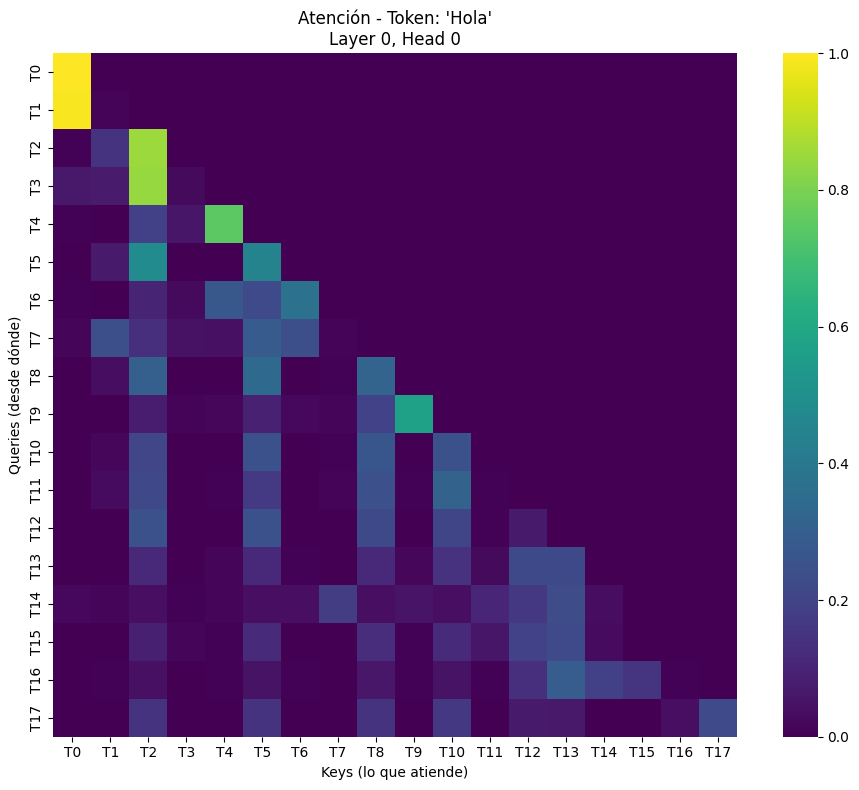

In [17]:
# Mostrar la cabeza 0 de la capa 0
visualize_last_token_attention(attention_data, layer_idx=0, head_idx=0)

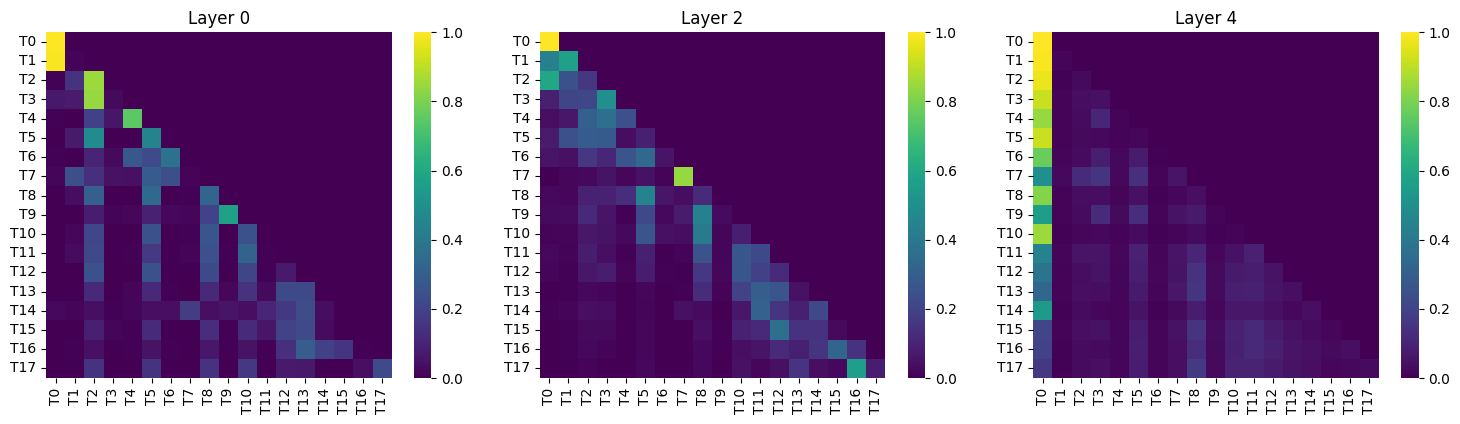

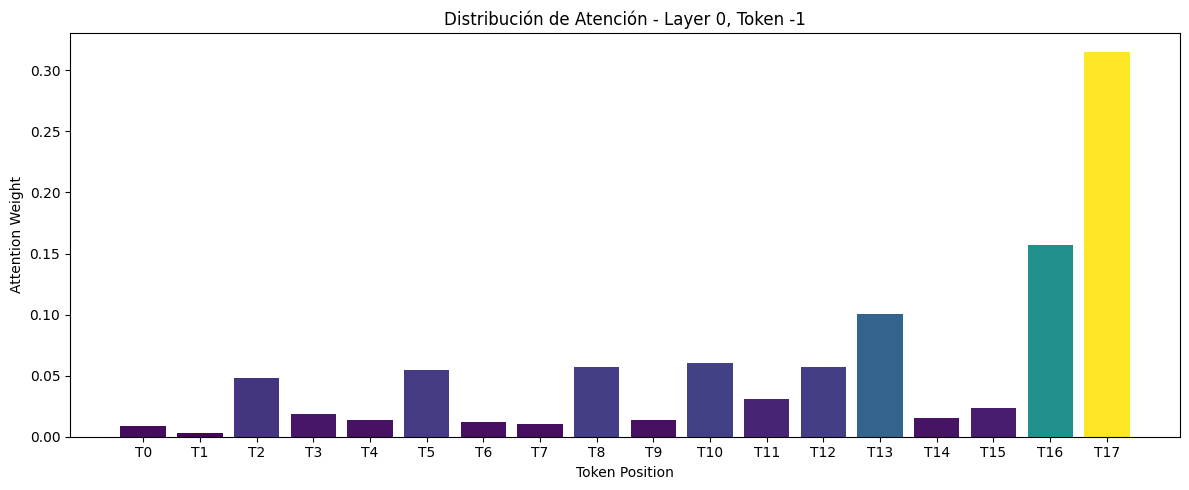

Token 0: '<think>' - Seq Length: 9
Token 1: '
' - Seq Length: 10
Token 2: 'Okay' - Seq Length: 11
Token 3: ',' - Seq Length: 12
Token 4: ' the' - Seq Length: 13
Token 5: ' user' - Seq Length: 14
Token 6: ' just' - Seq Length: 15
Token 7: ' said' - Seq Length: 16
Token 8: ' "' - Seq Length: 17
Token 9: 'Hola' - Seq Length: 18


In [18]:
# OPCIÓN 2: Comparar múltiples capas
compare_layer_attention(attention_data, layer_indices=[0, 2, 4], head_idx=0)

# OPCIÓN 3: Ver distribución de atención
plot_attention_distribution(attention_data, layer_idx=0, token_position=-1)

# OPCIÓN 4: Ver información resumida
for i, attn in enumerate(attention_data):
    print(f"Token {i}: '{attn['token_text']}' - Seq Length: {attn['seq_length']}")